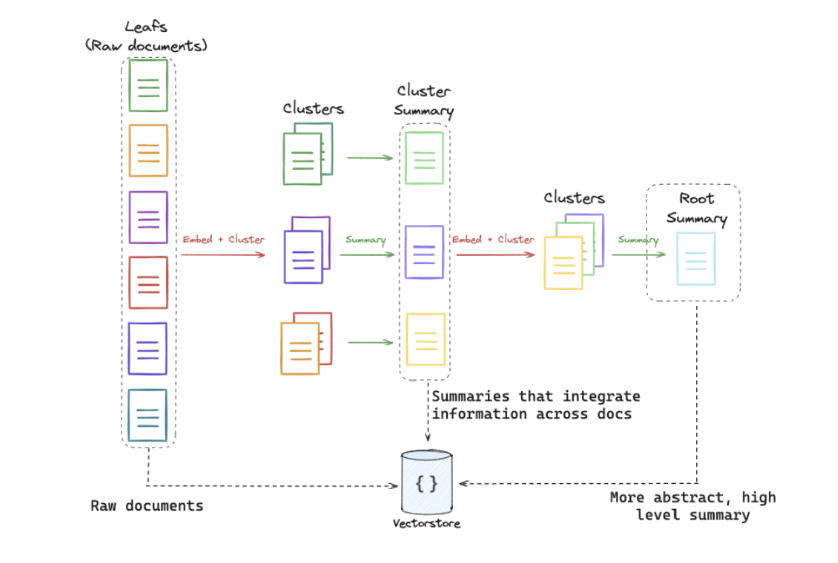

In [6]:
import os
import numpy as np
from typing import List, Dict
from umap import UMAP
from sklearn.mixture import GaussianMixture

from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFacePipeline, HuggingFaceEmbeddings

# ==========================================
# 1. INITIALIZE OPEN SOURCE MODELS & EMBEDDINGS
# ==========================================

# 1. Basic Baseline LLM (Ultra-lightweight, runs effortlessly on CPU)
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# Google's native text embedding model
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")

In [3]:
# ==========================================
# 2. RAPTOR ALGORITHMIC CLUSTERING CORE
# ==========================================
def cluster_embeddings(embeddings_matrix: np.ndarray, n_components: int = 3) -> List[np.ndarray]:
    """Reduces dimensionality and clusters embeddings using Gaussian Mixture Models."""
    # Reduce dimensions using UMAP so clustering math works efficiently
    umap_reducer = UMAP(n_neighbors=4, n_components=2, metric="cosine", random_state=42)
    reduced_embeddings = umap_reducer.fit_transform(embeddings_matrix)
    
    # Cluster using Gaussian Mixture Models (allows a chunk to share membership safely)
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    labels = gmm.fit_predict(reduced_embeddings)
    return labels

In [4]:
# ==========================================
# 3. RECURSIVE TREE BUILDER FUNCTION
# ==========================================
summary_prompt = ChatPromptTemplate.from_template(
    "Combine and summarize the following related texts into a single cohesive, higher-level abstract narrative:\n\n{text}"
)
summary_chain = summary_prompt | llm | StrOutputParser()

def build_raptor_tree(docs: List[Document], current_level: int = 0, max_levels: int = 3) -> List[Document]:
    """Recursively clusters and summarizes documents to build the RAPTOR tree."""
    print(f"Processing Layer {current_level} with {len(docs)} nodes...")
    
    # Base case: stop if we have too few docs or hit max height
    if len(docs) <= 3 or current_level >= max_levels:
        return docs
        
    # Get embeddings for current layer
    doc_texts = [d.page_content for d in docs]
    vectors = np.array(embeddings.embed_documents(doc_texts))
    
    # Cluster the vectors
    num_clusters = max(2, len(docs) // 3) # Dynamically size clusters
    labels = cluster_embeddings(vectors, n_components=num_clusters)
    
    # Group document texts by their cluster labels
    clustered_texts: Dict[int, List[str]] = {i: [] for i in range(num_clusters)}
    for idx, label in enumerate(labels):
        clustered_texts[label].append(doc_texts[idx])
        
    # Summarize each cluster to create the Parent Nodes for the next layer
    parent_nodes = []
    for label, texts in clustered_texts.items():
        if not texts: continue
        combined_text = "\n\n".join(texts)
        summary = summary_chain.invoke({"text": combined_text})
        
        # Track the summary as a new document node tagged with its layer metadata
        parent_nodes.append(Document(
            page_content=summary, 
            metadata={"source_layer": f"summary_level_{current_level + 1}"}
        ))
        
    # Recurse: Call the same function on the newly created summaries!
    return docs + build_raptor_tree(parent_nodes, current_level + 1, max_levels)


In [7]:
# ==========================================
# 4. DATA EXECUTION & INDEXING
# ==========================================
print("Loading documents...")
loader = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/")
raw_data = loader.load()

# Step A: Build Layer 0 (Leaf nodes)
leaf_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
leaf_docs = leaf_splitter.split_documents(raw_data)
for doc in leaf_docs:
    doc.metadata = {"source_layer": "leaf_0"}

# Step B: Run the recursive tree pipeline
all_tree_nodes = build_raptor_tree(leaf_docs, current_level=0, max_levels=2)
print(f"Total nodes created across the entire collapsed tree: {len(all_tree_nodes)}")

# Step C: Index EVERYTHING together into a single vector store
print("Indexing collapsed tree into Chroma...")
vectorstore = Chroma.from_documents(all_tree_nodes, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})


Loading documents...
Processing Layer 0 with 64 nodes...


c:\Users\asoha\Desktop\cse\langchain_learning\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing Layer 1 with 21 nodes...


c:\Users\asoha\Desktop\cse\langchain_learning\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Processing Layer 2 with 7 nodes...
Total nodes created across the entire collapsed tree: 92
Indexing collapsed tree into Chroma...


In [8]:
# ==========================================
# 5. FINAL LCEL GLOBAL RETRIEVAL CHAIN
# ==========================================
def format_docs(docs):
    formatted = []
    for doc in docs:
        layer = doc.metadata.get('source_layer', 'unknown')
        formatted.append(f"[{layer.upper()} CONTEXT]:\n{doc.page_content}")
    return "\n\n=================\n\n".join(formatted)

rag_prompt = ChatPromptTemplate.from_template("""
Analyze the question using the provided multi-layered contextual snippets. 
Synthesize an answer using both high-level summaries and low-level details provided.

Context Layers:
{context}

Question: {question}

Answer:""")

# End-to-End LCEL Pipeline
raptor_rag_chain = (
    {
        "context": retriever | format_docs,
        "question": RunnablePassthrough()
    }
    | rag_prompt
    | llm
    | StrOutputParser()
)

In [10]:
# Run a global macro-level query
query = "Provide a comprehensive overview of the design architecture and structural bottlenecks of building LLM agents."
print(f"\n--- Running Global Query: '{query}' ---")
print(raptor_rag_chain.invoke(query))


--- Running Global Query: 'Provide a comprehensive overview of the design architecture and structural bottlenecks of building LLM agents.' ---
To understand the current state of LLM-powered autonomous agents, one must view them as systems that position the LLM as a central "cognitive engine" designed to navigate complex, multi-step environments. The transition from experimental prototypes to robust, real-world systems requires balancing this cognitive potential with three fundamental architectural bottlenecks.

### Design Architecture: The Three Pillars
Modern agentic frameworks are built upon three foundational pillars designed to extend the reasoning capabilities of the LLM:

*   **Strategic Planning and Task Decomposition:** Agents utilize structured templates and hierarchical decomposition to break down complex goals into manageable steps. This allows the system to move beyond simple stimulus-response patterns toward goal-oriented behavior.
*   **Iterative Self-Reflection:** By sy